In [1]:
# this code is to produce PSDs, analysis, and the plots from 2D arrays of separated noise and event signals
# combined with csvCleaner into one larger script to run the analysis for the total outputs and inputs this should all work together

In [2]:
# also, want to save plotting responsibility for main script but will include matplot in this notebook for testing purposes

In [7]:
import pandas as pd
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Sans'
# plt.rcParams['figure.figsize'] = (3,2)
# plt.rcParams["figure.dpi"] = 300
import os

In [8]:
# first, for testing, we need to make said array of arrays
# it wont matter if we think this is noise or event, will work to test pipe all the same
# will be at 100 Hz, but will not *have* to be

timeGrid = np.arange(1443,3678,0.01)
noiseTimeGrid = []
for i in range(len(timeGrid)):
    diff = np.random.normal(0,0.005) # +- ~ 0.001 seconds, 10%
    noiseTimeGrid.append(timeGrid[i] + diff)
noiseTimeGrid = np.array(noiseTimeGrid)

noiseSignalA = 0.5 * np.sin(4*noiseTimeGrid/(2*np.pi))
noiseSignalB = 0.5 * np.sin(noiseTimeGrid/(2*np.pi))
noiseSignalC = 0.5 * np.sin(3*noiseTimeGrid/(2*np.pi))
noiseSignal1 = noiseSignalA + noiseSignalB
noiseSignal2 = (noiseSignalA + noiseSignalC)[10000:-10000]
noiseSignal3 = (noiseSignalB + noiseSignalC)[40000:-40000]

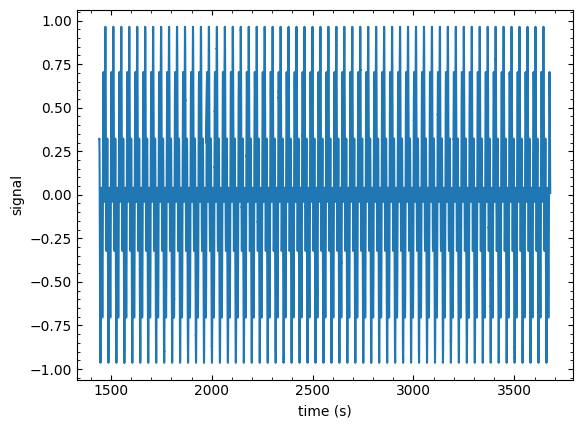

In [9]:
plt.plot(timeGrid,noiseSignal1)
plt.xlabel('time (s)')
plt.ylabel('signal')
plt.show()

In [10]:
noiseArrs = []
noiseArrs.append(noiseSignal1)
noiseArrs.append(noiseSignal2)
noiseArrs.append(noiseSignal3)
noiseArrs

[array([0.32215343, 0.32224106, 0.32228413, ..., 0.0135022 , 0.01190109,
        0.01019247], shape=(223500,)),
 array([ 0.92512141,  0.92371024,  0.91982882, ..., -0.38730374,
        -0.38850612, -0.38968429], shape=(203500,)),
 array([-0.29881536, -0.29800881, -0.29420363, ...,  0.38277987,
         0.38391436,  0.38707423], shape=(143500,))]